# Import Modules and Functions

In [1]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
### Read in data that has been flagged for good indices

lc_df1i = readin_LCdf('LC_tables/modified_data/LCtable1_i.csv')
lc_df1g = readin_LCdf('LC_tables/modified_data/LCtable1_g.csv')
lc_df1r = readin_LCdf('LC_tables/modified_data/LCtable1_r.csv')
lc_df1z = readin_LCdf('LC_tables/modified_data/LCtable1_z.csv')

lc_df2i = readin_LCdf('LC_tables/modified_data/LCtable2_i.csv')
lc_df2g = readin_LCdf('LC_tables/modified_data/LCtable2_g.csv')
lc_df2r = readin_LCdf('LC_tables/modified_data/LCtable2_r.csv')
lc_df2z = readin_LCdf('LC_tables/modified_data/LCtable2_z.csv')

lc_df3i = readin_LCdf('LC_tables/modified_data/LCtable3_i.csv')
lc_df3g = readin_LCdf('LC_tables/modified_data/LCtable3_g.csv')
lc_df3r = readin_LCdf('LC_tables/modified_data/LCtable3_r.csv')
lc_df3z = readin_LCdf('LC_tables/modified_data/LCtable3_z.csv')

lc_df4i = readin_LCdf('LC_tables/modified_data/LCtable4_i.csv')
lc_df4g = readin_LCdf('LC_tables/modified_data/LCtable4_g.csv')
lc_df4r = readin_LCdf('LC_tables/modified_data/LCtable4_r.csv')
lc_df4z = readin_LCdf('LC_tables/modified_data/LCtable4_z.csv')


lc_dfs1 = [lc_df1g, lc_df1r, lc_df1i, lc_df1z]
lc_dfs2 = [lc_df2g, lc_df2r, lc_df2i, lc_df2z]
lc_dfs3 = [lc_df3g, lc_df3r, lc_df3i, lc_df3z]
lc_dfs4 = [lc_df4g, lc_df4r, lc_df4i, lc_df4z]

In [4]:
### Read in iteration 1 LC model
LCmod_g = readin_LCdf('LC_tables/models/gLC_mod1.csv')
LCmod_r = readin_LCdf('LC_tables/models/rLC_mod1.csv')
LCmod_i = readin_LCdf('LC_tables/models/iLC_mod1.csv')
LCmod_z = readin_LCdf('LC_tables/models/zLC_mod1.csv')
LCmods = [LCmod_g, LCmod_r, LCmod_i, LCmod_z]

### Data of iteration 1
LCdat_g = readin_LCdf('LC_tables/models/gLC_data1.csv')
LCdat_r = readin_LCdf('LC_tables/models/rLC_data1.csv')
LCdat_i = readin_LCdf('LC_tables/models/iLC_data1.csv')
LCdat_z = readin_LCdf('LC_tables/models/zLC_data1.csv')
LCdats = [LCdat_g, LCdat_r, LCdat_i, LCdat_z]

# Fitting Process

In [5]:
### Fit light curves to the model per filter simultaneously

mcres_1 = loop_allemcee(lc_dfs1, LCmodels=LCmods, peak_l='main')
mcres_2 = loop_allemcee(lc_dfs2, LCmodels=LCmods, peak_l='main')
mcres_3 = loop_allemcee(lc_dfs3, LCmodels=LCmods, peak_l='plat')
mcres_4 = loop_allemcee(lc_dfs4, LCmodels=LCmods, peak_l=None)

In [6]:
### Combine aligned light curves into one data frame per segment per filter

comb1 = get_allcombLCs(lc_dfs1, mcres_1, LCmodel=LCmods)
comb2 = get_allcombLCs(lc_dfs2, mcres_2, LCmodel=LCmods)
comb3 = get_allcombLCs(lc_dfs3, mcres_3, LCmodel=LCmods)
comb4 = get_allcombLCs(lc_dfs4, mcres_4, LCmodel=LCmods)

In [7]:
### Combine aligned data of the four segments per filter

fin_combs = comb_allcomb([comb1, comb2, comb3, comb4], [None]*4, [0.0]*4)

In [28]:
### Create model
fmods = [optimizeGP_celer(fcb, lc_ID=None, smoother=True) for fcb in fin_combs]

In [31]:
### Sigma cut using model
fin_inds = [sigmacut_df(fin_combs[i], fmods[i], sigma=3.0) for i in range(len(fin_combs))]

In [34]:
### Create final model
fin_mods = [optimizeGP_celer(fin_combs[i], lc_ID=None, indices=fin_inds[i], smoother=True) for i in range(len(fin_combs))]

In [24]:
### Define phase relative to main peak

set_peak(fin_combs,fin_mods)

'Updated phase'

In [27]:
### Save tables

fin_combs[0].t.to_csv('LC_tables/models/gLC_data2.csv', index=False)
fin_combs[1].t.to_csv('LC_tables/models/rLC_data2.csv', index=False)
fin_combs[2].t.to_csv('LC_tables/models/iLC_data2.csv', index=False)
fin_combs[3].t.to_csv('LC_tables/models/zLC_data2.csv', index=False)

fin_mods[0].t.to_csv('LC_tables/models/gLC_mod2.csv', index=False)
fin_mods[1].t.to_csv('LC_tables/models/rLC_mod2.csv', index=False)
fin_mods[2].t.to_csv('LC_tables/models/iLC_mod2.csv', index=False)
fin_mods[3].t.to_csv('LC_tables/models/zLC_mod2.csv', index=False)

# Plot

In [11]:
### See fits

# plot_allLCfits(lc_dfs4, mcres_4, LCmodel=LCmods)

In [12]:
### Plot segments

# sflt = 2
# see_combs = [comb1[sflt], comb2[sflt], comb3[sflt], comb4[sflt]]

# plt.errorbar(see_combs[0].t['mjd'], see_combs[0].t['muJyas2'], yerr=see_combs[0].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb1i, mu_comb1i, color='k', zorder=5)
# plt.show()

# plt.errorbar(see_combs[1].t['mjd'], see_combs[1].t['muJyas2'], yerr=see_combs[1].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb2i, mu_comb2i, color='k', zorder=5)
# plt.show()

# plt.errorbar(see_combs[2].t['mjd'], see_combs[2].t['muJyas2'], yerr=see_combs[2].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb3i, mu_comb3i, color='k', zorder=5)
# plt.show()

# plt.errorbar(see_combs[3].t['mjd'], see_combs[3].t['muJyas2'], yerr=see_combs[3].t['muJyas2_err'], fmt='.')
# # plt.plot(trange_comb4i, mu_comb4i, color='k', zorder=5)
# plt.show()

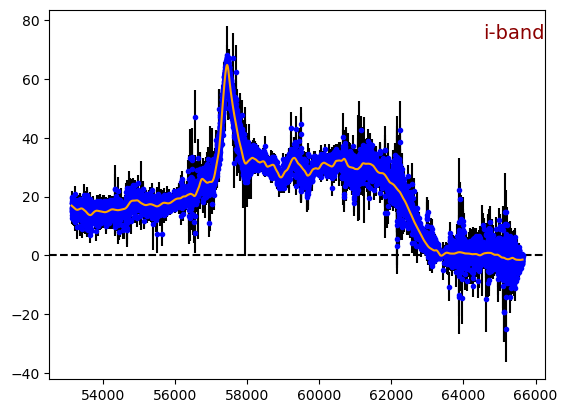

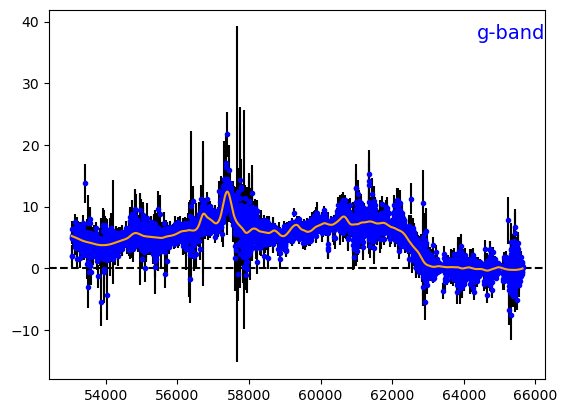

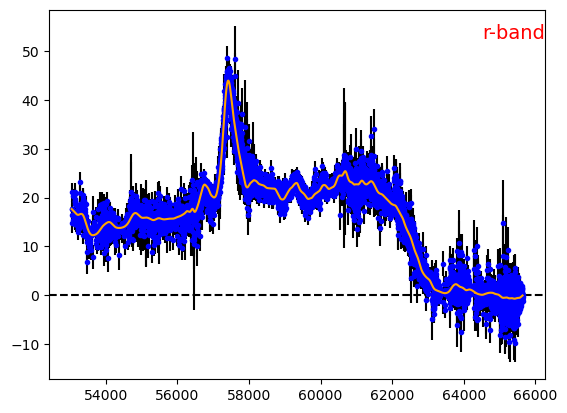

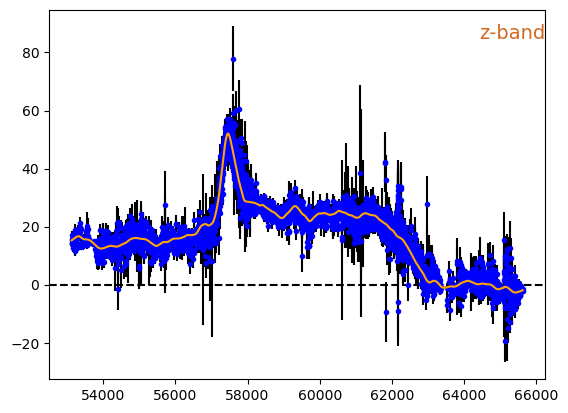

In [35]:
### Plot final segment-connected, aligned data and model

plt.errorbar(fin_combs[2].t.loc[fin_inds[2],'mjd'], fin_combs[2].t.loc[fin_inds[2],'muJyas2'], fmt='.', ecolor='black', color='blue', yerr=fin_combs[2].t.loc[fin_inds[2],'muJyas2_err'])
plt.errorbar(fin_mods[2].t['mjd'], fin_mods[2].t['muJyas2'], yerr=fin_mods[2].t['muJyas2_err'], color='orange')
# plt.ylim(-15, 75)
plt.axhline(0, ls='--', color='k')
plt.title('i-band', loc='right', y=0.9, color='darkred', fontsize=14.)
plt.show()

plt.errorbar(fin_combs[0].t.loc[fin_inds[0],'mjd'], fin_combs[0].t.loc[fin_inds[0],'muJyas2'], fmt='.', ecolor='black', color='blue', yerr=fin_combs[0].t.loc[fin_inds[0],'muJyas2_err'])
plt.errorbar(fin_mods[0].t['mjd'], fin_mods[0].t['muJyas2'], yerr=fin_mods[0].t['muJyas2_err'], color='orange')
# plt.ylim(-60, 30)
plt.axhline(0, ls='--', color='k')
plt.title('g-band', loc='right', y=0.9, color='blue', fontsize=14.)
plt.show()

plt.errorbar(fin_combs[1].t.loc[fin_inds[1],'mjd'], fin_combs[1].t.loc[fin_inds[1],'muJyas2'], fmt='.', ecolor='black', color='blue', yerr=fin_combs[1].t.loc[fin_inds[1],'muJyas2_err'])
plt.errorbar(fin_mods[1].t['mjd'], fin_mods[1].t['muJyas2'], yerr=fin_mods[1].t['muJyas2_err'], color='orange')
# plt.ylim(-60, 30)
plt.axhline(0, ls='--', color='k')
plt.title('r-band', loc='right', y=0.9, color='red', fontsize=14.)
plt.show()

plt.errorbar(fin_combs[3].t.loc[fin_inds[3],'mjd'], fin_combs[3].t.loc[fin_inds[3],'muJyas2'], fmt='.', ecolor='black', color='blue', yerr=fin_combs[3].t.loc[fin_inds[3],'muJyas2_err'])
plt.errorbar(fin_mods[3].t['mjd'], fin_mods[3].t['muJyas2'], yerr=fin_mods[3].t['muJyas2_err'], color='orange')
# plt.ylim(-60, 30)
plt.axhline(0, ls='--', color='k')
plt.title('z-band', loc='right', y=0.9, color='chocolate', fontsize=14.)
plt.show()

In [30]:
# tt_g, ff_g, eerr_g, ppeak_g = get_tferr(fmods[0], peak_l='main')
# tt_r, ff_r, eerr_r, ppeak_r = get_tferr(fmods[1], peak_l='main')
# tt_i, ff_i, eerr_i, ppeak_i = get_tferr(fmods[2], peak_l='main')
# tt_z, ff_z, eerr_z, ppeak_z = get_tferr(fmods[3], peak_l='main')

# fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
# axs = axs.flatten()

# axs[0].errorbar(tt_i, ff_i, fmt='.', ecolor='black', color='blue', yerr=eerr_i, label='i-band')
# axs[0].axvline(ppeak_i, color='purple')
# axs[0].legend(fontsize = 14)

# axs[1].errorbar(tt_g, ff_g, fmt='.', ecolor='black', color='blue', yerr=eerr_g, label='g-band')
# axs[1].axvline(ppeak_g, color='purple')
# axs[1].legend(fontsize = 14)

# axs[2].errorbar(tt_r, ff_r, fmt='.', ecolor='black', color='blue', yerr=eerr_r, label='r-band')
# axs[2].axvline(ppeak_r, color='purple')
# axs[2].legend(fontsize = 14)

# axs[3].errorbar(tt_z, ff_z, fmt='.', ecolor='black', color='blue', yerr=eerr_z, label='z-band')
# axs[3].axvline(ppeak_z, color='purple')
# axs[3].legend(fontsize = 14)

# fig.subplots_adjust(wspace=0, hspace=0)